<a href="https://colab.research.google.com/github/Zahab163/ebay-car--sales-exploration/blob/main/Car_Ebay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction of Project:
### Exploring eBay Car Sales Data
In this project we are going through a real-world data analysis project using pandas to explore and clean a dataset of used car listings scraped from eBay Kleinanzeigen, the German eBay classifieds site.As we will step into the role of a data analyst for a used car classifieds service, tackling the kind of messy, real-world data challenges

In [1]:

import kagglehub

# Download latest version
path = kagglehub.dataset_download("sijovm/used-cars-data-from-ebay-kleinanzeigen")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'used-cars-data-from-ebay-kleinanzeigen' dataset.
Path to dataset files: /kaggle/input/used-cars-data-from-ebay-kleinanzeigen


In [2]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
# Read dataset
import os
file_name = "autos.csv" # Assuming the CSV file is named 'autos.csv'
file_path = os.path.join(path, file_name)
Autos = pd.read_csv(file_path, encoding='latin1')

# Display head
Autos.head()

,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
0,2016-03-24 11:52:17,Golf_3_1.6,privat,Angebot,480,test,NaN,1993,manuell,0,golf,150000,0,benzin,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,A5_Sportback_2.7_Tdi,privat,Angebot,18300,test,coupe,2011,manuell,190,NaN,125000,5,diesel,audi,ja,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,"Jeep_Grand_Cherokee_""Overland""",privat,Angebot,9800,test,suv,2004,automatik,163,grand,125000,8,diesel,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,GOLF_4_1_4__3TÜRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,75,golf,150000,6,benzin,volkswagen,nein,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,69,fabia,90000,7,diesel,skoda,nein,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


In [4]:
# Displaying the end of dataset
Autos.tail()

,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
371523,2016-03-14 17:48:27,Suche_t4___vito_ab_6_sitze,privat,Angebot,2200,test,NaN,2005,NaN,0,NaN,20000,1,NaN,sonstige_autos,NaN,2016-03-14 00:00:00,0,39576,2016-04-06 00:46:52
371524,2016-03-05 19:56:21,Smart_smart_leistungssteigerung_100ps,privat,Angebot,1199,test,cabrio,2000,automatik,101,fortwo,125000,3,benzin,smart,nein,2016-03-05 00:00:00,0,26135,2016-03-11 18:17:12
371525,2016-03-19 18:57:12,Volkswagen_Multivan_T4_TDI_7DC_UY2,privat,Angebot,9200,test,bus,1996,manuell,102,transporter,150000,3,diesel,volkswagen,nein,2016-03-19 00:00:00,0,87439,2016-04-07 07:15:26
371526,2016-03-20 19:41:08,VW_Golf_Kombi_1_9l_TDI,privat,Angebot,3400,test,kombi,2002,manuell,100,golf,150000,6,diesel,volkswagen,NaN,2016-03-20 00:00:00,0,40764,2016-03-24 12:45:21
371527,2016-03-07 19:39:19,BMW_M135i_vollausgestattet_NP_52.720____Euro,privat,Angebot,28990,control,limousine,2013,manuell,320,m_reihe,50000,8,benzin,bmw,nein,2016-03-07 00:00:00,0,73326,2016-03-22 03:17:10


Data dictionary for the dataset:

dateCrawled - When the ad was first crawled. All field-values are taken from this date.
name - Name of the car.
seller - Whether the seller is private or a dealer.
offerType - The type of listing.
price - The listed selling price of the car.
abtest - Whether the listing is included in an A/B test.
vehicleType - The type of vehicle.
yearOfRegistration - The year in which the car was first registered.
gearbox - The type of transmission.
powerPS - The power of the car in PS.
model - The car model name.
odometer - How many kilometers the car has driven.
monthOfRegistration - The month in which the car was first registered.
fuelType - What type of fuel the car uses.
brand - The brand of the car.
notRepairedDamage - If the car has a damage which is not yet repaired.
dateCreated - The date the eBay listing was created.
nrOfPictures - The number of pictures in the ad.
postalCode - The postal code for the location of the vehicle.
lastSeenOnline - When the crawler saw this ad last online.

In [5]:
# Displaying information about dataframe
Autos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371528 entries, 0 to 371527
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   dateCrawled          371528 non-null  object
 1   name                 371528 non-null  object
 2   seller               371528 non-null  object
 3   offerType            371528 non-null  object
 4   price                371528 non-null  int64 
 5   abtest               371528 non-null  object
 6   vehicleType          333659 non-null  object
 7   yearOfRegistration   371528 non-null  int64 
 8   gearbox              351319 non-null  object
 9   powerPS              371528 non-null  int64 
 10  model                351044 non-null  object
 11  kilometer            371528 non-null  int64 
 12  monthOfRegistration  371528 non-null  int64 
 13  fuelType             338142 non-null  object
 14  brand                371528 non-null  object
 15  notRepairedDamage    299468 non-nu

We could see we have 20 columns here from which we can see that there are a lot of Data Type = Object

The column names use camelcase instead of Python's preferred snakecase, which means we can't just replace spaces with underscores.

and yes as we could see there are many words which are not in English , cause it's Germany's Ebay ... We will change it to .

In [6]:
Autos.columns

Index(['dateCrawled', 'name', 'seller', 'offerType', 'price', 'abtest',
       'vehicleType', 'yearOfRegistration', 'gearbox', 'powerPS', 'model',
       'kilometer', 'monthOfRegistration', 'fuelType', 'brand',
       'notRepairedDamage', 'dateCreated', 'nrOfPictures', 'postalCode',
       'lastSeen'],
      dtype='object')

In [7]:
Autos.columns = [ 'data_crawled', 'name', 'seller', 'offer_type', 'price',
                 'ab_test', 'vechicle_type','registration_year', 'gearbox',
                  'power_ps', 'model', 'odometer', 'registration_month',
                  'fuel_type', 'brand', 'unrepaired_damage', 'ad_created',
                  'num_photos', 'postal_code', 'last_seen']

we keep the same order so that pandas will do as it is .

We use DataFrame.head() to look at the current state of the autos dataframe.

In [8]:
Autos.head()

,data_crawled,name,seller,offer_type,price,ab_test,vechicle_type,registration_year,gearbox,power_ps,model,odometer,registration_month,fuel_type,brand,unrepaired_damage,ad_created,num_photos,postal_code,last_seen
0,2016-03-24 11:52:17,Golf_3_1.6,privat,Angebot,480,test,NaN,1993,manuell,0,golf,150000,0,benzin,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,A5_Sportback_2.7_Tdi,privat,Angebot,18300,test,coupe,2011,manuell,190,NaN,125000,5,diesel,audi,ja,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,"Jeep_Grand_Cherokee_""Overland""",privat,Angebot,9800,test,suv,2004,automatik,163,grand,125000,8,diesel,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,GOLF_4_1_4__3TÜRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,75,golf,150000,6,benzin,volkswagen,nein,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,69,fabia,90000,7,diesel,skoda,nein,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


As we can see that array and make the following edits to columns names:
yearOfRegistration to registration_year
monthOfRegistration to registration_month
notRepairedDamage to unrepaired_damage
dateCreated to ad_created

In [9]:
Autos.describe(include='all')

,data_crawled,name,seller,offer_type,price,ab_test,vechicle_type,registration_year,gearbox,power_ps,model,odometer,registration_month,fuel_type,brand,unrepaired_damage,ad_created,num_photos,postal_code,last_seen
count,371528,371528,371528,371528,3.715280e+05,371528,333659,371528.000000,351319,371528.000000,351044,371528.000000,371528.000000,338142,371528,299468,371528,371528.0,371528.00000,371528
unique,280500,233531,2,2,NaN,2,8,NaN,2,NaN,251,NaN,NaN,7,40,2,114,NaN,NaN,182806
top,2016-03-24 14:49:47,Ford_Fiesta,privat,Angebot,NaN,test,limousine,NaN,manuell,NaN,golf,NaN,NaN,benzin,volkswagen,nein,2016-04-03 00:00:00,NaN,NaN,2016-04-06 13:45:54
freq,7,657,371525,371516,NaN,192585,95894,NaN,274214,NaN,30070,NaN,NaN,223857,79640,263182,14450,NaN,NaN,17
mean,NaN,NaN,NaN,NaN,1.729514e+04,NaN,NaN,2004.577997,NaN,115.549477,NaN,125618.688228,5.734445,NaN,NaN,NaN,NaN,0.0,50820.66764,NaN
std,NaN,NaN,NaN,NaN,3.587954e+06,NaN,NaN,92.866598,NaN,192.139578,NaN,40112.337051,3.712412,NaN,NaN,NaN,NaN,0.0,25799.08247,NaN
min,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,1000.000000,NaN,0.000000,NaN,5000.000000,0.000000,NaN,NaN,NaN,NaN,0.0,1067.00000,NaN
25%,NaN,NaN,NaN,NaN,1.150000e+03,NaN,NaN,1999.000000,NaN,70.000000,NaN,125000.000000,3.000000,NaN,NaN,NaN,NaN,0.0,30459.00000,NaN
50%,NaN,NaN,NaN,NaN,2.950000e+03,NaN,NaN,2003.000000,NaN,105.000000,NaN,150000.000000,6.000000,NaN,NaN,NaN,NaN,0.0,49610.00000,NaN
75%,NaN,NaN,NaN,NaN,7.200000e+03,NaN,NaN,2008.000000,NaN,150.000000,NaN,150000.000000,9.000000,NaN,NaN,NaN,NaN,0.0,71546.00000,NaN


In [10]:
Autos['num_photos'].value_counts()

,count
num_photos,
0,371528


We are dropping columns and we added axis =1 .. if we want to drop rows we will write axis = 0

In [11]:
autos = Autos.drop(['num_photos', 'seller', 'offer_type'], axis=1)

We are changing the object columns to interger for processing it for Ml modelling

In [12]:
autos["price"] = autos["price"].astype(int)
autos["price"].head()

,price
0,480
1,18300
2,9800
3,1500
4,3600


In [13]:
autos["odometer"] = autos["odometer"].astype(int)
autos["odometer"].head()

,odometer
0,150000
1,125000
2,125000
3,150000
4,90000


In [14]:
#Changing the name of column for understanding
autos.rename({"odometer":"odometer_km"}, axis=1, inplace=True)
autos["odometer_km"].head()

,odometer_km
0,150000
1,125000
2,125000
3,150000
4,90000


In [15]:
autos['odometer_km'].value_counts()

,count
odometer_km,
150000,240797
125000,38067
100000,15920
90000,12523
80000,11053
70000,9773
60000,8669
50000,7615
5000,7069


We are assumming with it that there is drop down column was used.


In [16]:
print(autos["price"].unique().shape)
print(autos["price"].describe())
autos["price"].value_counts().head(20)

(5597,)
count    3.715280e+05
mean     1.729514e+04
std      3.587954e+06
min      0.000000e+00
25%      1.150000e+03
50%      2.950000e+03
75%      7.200000e+03
max      2.147484e+09
Name: price, dtype: float64


,count
price,
0,10778
500,5670
1500,5394
1000,4649
1200,4594
2500,4438
600,3819
3500,3792
800,3784


we could see there are min ammount of zero , and there are a lot of no. of cars sold in that ammount which could be error , so we will remove it .and we will see in max values too cause these prices seems outliers .

In [17]:
autos["price"].value_counts().sort_index(ascending=False).head(20)

,count
price,
2147483647,1
99999999,15
99000000,1
74185296,1
32545461,1
27322222,1
14000500,1
12345678,9
11111111,10


we are going to remove much larger amounts cause they seems outliers.

In [18]:
autos["price"].value_counts().sort_index(ascending=True).head(20)

,count
price,
0,10778
1,1189
2,12
3,8
4,1
5,26
7,3
8,9
9,8


In [19]:
autos = autos[autos["price"]. between(100,3895000)]
autos["price"].describe()


,price
count,3.581560e+05
mean,6.111270e+03
std,1.824469e+04
min,1.000000e+02
25%,1.290000e+03
50%,3.100000e+03
75%,7.500000e+03
max,3.895000e+06


ok i did not go with 1 dollar as guided project cause i'm not imaging any thing in 1  dollar or german currency

We are going with registration_year column

In [20]:
autos["registration_year"].describe()

,registration_year
count,358156.000000
mean,2004.326375
std,74.379331
min,1000.000000
25%,1999.000000
50%,2004.000000
75%,2008.000000
max,9999.000000


As we could see a large difference  so we will keep from 1900 to 2016 cause 2016 is the final year of the data set.

In [21]:
(~autos["registration_year"].between(1900, 2016)).sum() / autos.shape[0]

np.float64(0.038742894157853)

We use ~ to say which are not from these years .. so now we will remove it.

In [22]:
autos = autos[autos["registration_year"].between(1900, 2016)]
autos["registration_year"].value_counts(normalize=True).head(10)


,proportion
registration_year,
2000,0.065981
1999,0.063562
2005,0.062647
2006,0.058002
2001,0.057119
2003,0.056814
2004,0.056454
2002,0.054517
2007,0.050729


We are going to see which brands are selling in German Ebay

In [23]:
autos["brand"].value_counts(normalize=True)

,proportion
brand,
volkswagen,0.211833
bmw,0.109940
opel,0.106169
mercedes_benz,0.097075
audi,0.089741
ford,0.068691
renault,0.047424
peugeot,0.030153
fiat,0.025668


We are going to most common brands as they have more than 5 % of instances.

In [24]:
brand_counts = autos["brand"].value_counts(normalize=True)
common_brands = brand_counts[brand_counts > 0.05].index
print(common_brands)

Index(['volkswagen', 'bmw', 'opel', 'mercedes_benz', 'audi', 'ford'], dtype='object', name='brand')


We check the prices for the brands alongside it

In [25]:
brand_mean_prices = {}

for brand in common_brands:
    brand_only = autos[autos["brand"] == brand]
    mean_price = brand_only["price"].mean()
    brand_mean_prices[brand] = int(mean_price)

brand_mean_prices

{'volkswagen': 5486,
 'bmw': 8629,
 'opel': 3056,
 'mercedes_benz': 8648,
 'audi': 9210,
 'ford': 3818}

We change it into Data Frame

In [26]:
bmp_series = pd.Series(brand_mean_prices)
pd.DataFrame(bmp_series, columns=["mean_price"])

,mean_price
volkswagen,5486
bmw,8629
opel,3056
mercedes_benz,8648
audi,9210
ford,3818


In [27]:
bmp_series = pd.Series(brand_mean_prices)
autos_df = pd.DataFrame(bmp_series, columns=["mean_price"])


We are going to visualize them

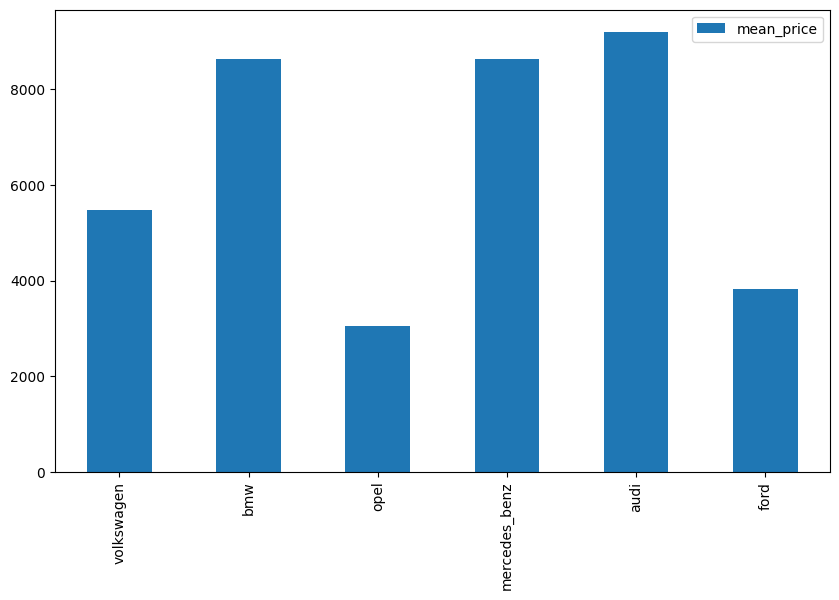

In [28]:
import matplotlib.pyplot as plt

bmp_series = pd.Series(brand_mean_prices)
autos_df = pd.DataFrame(bmp_series, columns=["mean_price"])
autos_df.plot(kind='bar', figsize=(10, 6))
plt.show()

As we can see mean prices for audi, bmw and mercedes_benz are high in this chart.

we are going to do similar thing for mileage .. we made a dictionary

In [29]:
brand_mean_mileage = {}

for brand in common_brands:
    brand_only = autos[autos["brand"] == brand]
    mean_mileage = brand_only["odometer_km"].mean()
    brand_mean_mileage[brand] = int(mean_mileage)

mean_mileage = pd.Series(brand_mean_mileage).sort_values(ascending=False)
mean_prices = pd.Series(brand_mean_prices).sort_values(ascending=False)

brand_info = pd.DataFrame(mean_mileage,columns=['mean_mileage'])
brand_info

,mean_mileage
bmw,132980
mercedes_benz,130726
audi,129540
opel,128801
volkswagen,128502
ford,123709


mileage are not being vary as it was for mean prices

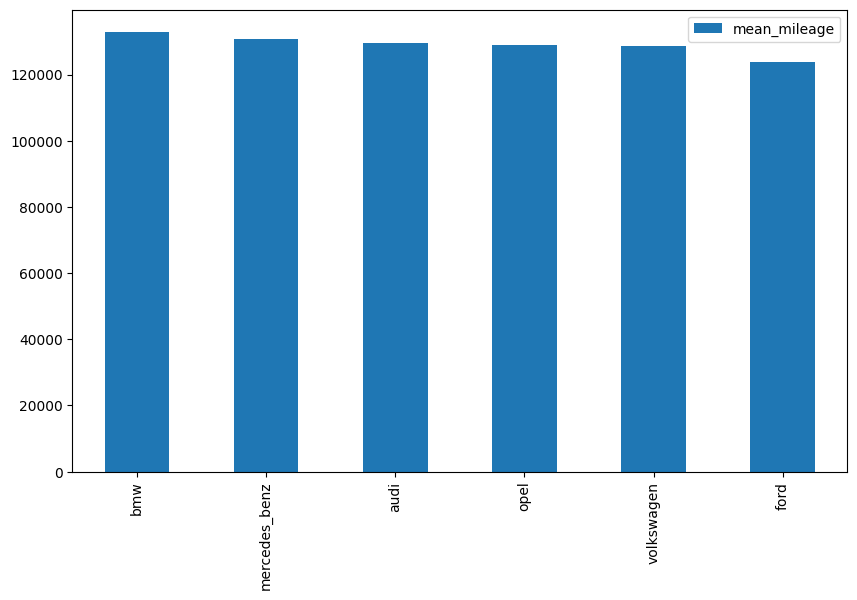

In [30]:
#visualizing in plot chart
brand_info.plot(kind='bar', figsize=(10, 6))
plt.show()

In [31]:
brand_info["mean_price"] = mean_prices
brand_info

,mean_mileage,mean_price
bmw,132980,8629
mercedes_benz,130726,8648
audi,129540,9210
opel,128801,3056
volkswagen,128502,5486
ford,123709,3818


if we want to sell the cars by this chart bmw, mercedes_benz and audi would be highly sells and we can assume volswagen will hit the sweet spot.cause it's not higher end but also not the lower end.

Finding the most common / brand combination

In [32]:
brand_model_counts = autos.groupby(['brand', 'model']).size().sort_values(ascending=False)
display(brand_model_counts.head(20))

brand          model      
volkswagen     golf           27395
bmw            3er            19369
volkswagen     polo           11940
opel           corsa          11446
               astra           9978
audi           a4              9759
volkswagen     passat          9681
mercedes_benz  c_klasse        8429
bmw            5er             8157
mercedes_benz  e_klasse        7227
audi           a3              6150
               a6              5717
ford           focus           5572
               fiesta          5369
volkswagen     transporter     5198
peugeot        2_reihe         4632
renault        twingo          4467
smart          fortwo          4141
mercedes_benz  a_klasse        3961
opel           vectra          3913
dtype: int64

As you can see, 'volkswagen' 'golf' is the most frequent combination with 27,395 listings, followed by 'bmw' '3er' with 19,369 listings. This output helps in understanding which car models from specific brands are most prevalent in the eBay listings.



split the odometer_kminto groups and use aggregation to see the average prices follows any patterns based on the mileage.

In [33]:
mileage_bins = [0, 50000, 100000, 150000]
mileage_labels = ['0-50k', '50k-100k', '100k-150k']

autos['odometer_group'] = pd.cut(autos['odometer_km'], bins=mileage_bins, labels=mileage_labels, right=False)

mileage_price_patterns = autos.groupby('odometer_group', observed=False)['price'].mean().sort_values(ascending=False)
display(mileage_price_patterns)

,price
odometer_group,
0-50k,16754.088167
50k-100k,10797.606859
100k-150k,6924.652365


#### Average Price by Odometer Group

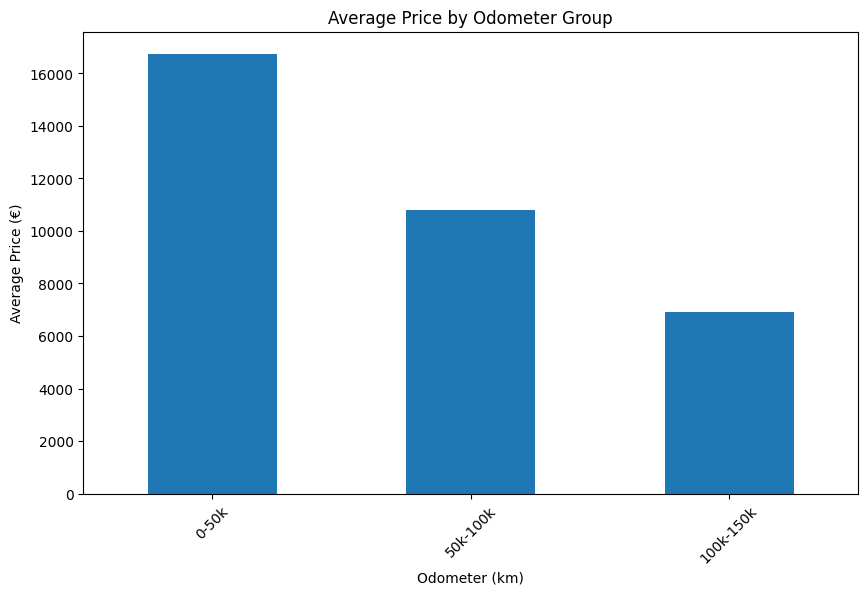

In [34]:
import matplotlib.pyplot as plt

mileage_price_patterns.plot(kind='bar', figsize=(10, 6))
plt.title('Average Price by Odometer Group')
plt.xlabel('Odometer (km)')
plt.ylabel('Average Price (€)')
plt.xticks(rotation=45)
plt.show()

odometer_km into ranges (0-50k, 50k-100k, and 100k-150k) and calculated the average price for each group. As the output shows, cars with lower mileage (0-50k) have the highest average price (€16,754), which decreases as the mileage increases (€10,797 for 50k-100k, and €6,924 for 100k-150k). This pattern is also clearly visible in the bar chart.

how much cheapers are cars with damage than their non damage  counterparts?

Visualize the price difference based on unrepaired damage status

To determine how much cheaper cars with damage are, I will calculate the average price for cars with unrepaired damage and compare it to cars without unrepaired damage. First, I'll fill any missing values in the unrepaired_damage column.

In [35]:
# Fill NaN values in 'unrepaired_damage' with 'nicht_angegeben' (not specified)
autos['unrepaired_damage'] = autos['unrepaired_damage'].fillna('nicht_angegeben')

# Calculate the average price for each category of 'unrepaired_damage'
damage_price_comparison = autos.groupby('unrepaired_damage')['price'].mean().sort_values(ascending=False)
display(damage_price_comparison)

,price
unrepaired_damage,
nein,7332.351635
nicht_angegeben,3504.363891
ja,2365.025270


cars with no unrepaired damage ('nein') have a significantly higher average price compared to those with unspecified damage ('nicht_angegeben') or confirmed unrepaired damage ('ja'). This plot clearly illustrates the price penalty associated with cars that have or might have damage.

#### Average Price by Unrepaired Damage Status

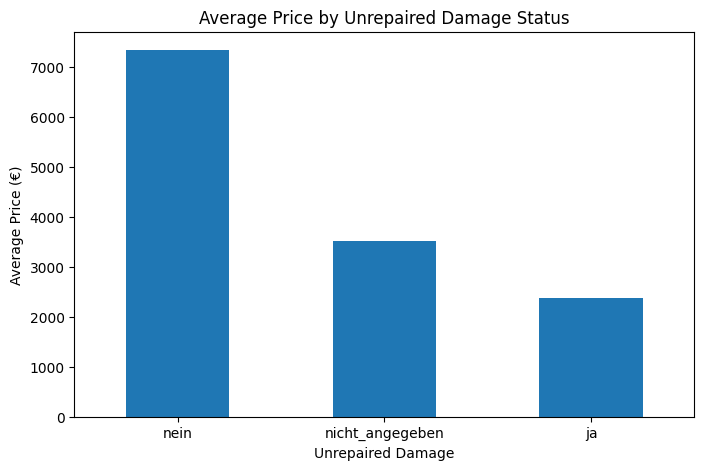

In [36]:
import matplotlib.pyplot as plt

damage_price_comparison.plot(kind='bar', figsize=(8, 5))
plt.title('Average Price by Unrepaired Damage Status')
plt.xlabel('Unrepaired Damage')
plt.ylabel('Average Price (€)')
plt.xticks(rotation=0)
plt.show()

The analysis shows a clear price difference based on the unrepaired_damage status. Cars without unrepaired damage (nein) have the highest average price at approximately €7,332. Cars with unspecified damage (nicht_angegeben) are significantly cheaper, averaging around €3,504. The cheapest cars are those explicitly listed with unrepaired damage (ja), with an average price of about €2,365. This indicates that cars with damage, or even those where damage status is not specified, are considerably cheaper than their undamaged counterparts. The bar chart provides a visual representation of these price differences.

##Project Summary: Exploring eBay Car Sales Data
This Colab notebook delves into a real-world data analysis project using a dataset of used car listings scraped from eBay Kleinanzeigen, a German classifieds site. The primary goal was to explore and clean the data, mimicking the role of a data analyst for a used car classifieds service.

###Key Steps and Findings:

1. **Data Loading and Initial Inspection**: The Autos dataset was loaded, and an initial inspection revealed column names, data types, and descriptive statistics. Several columns were renamed to adopt a more Python-friendly snake_case convention, enhancing readability and maintainability.

2. **Data Cleaning and Transformation:**

* **Irrelevant Columns**: Columns like num_photos, seller, and offer_type were identified as having little analytical value (e.g., num_photos contained only zero values) and were subsequently dropped.
* **Numeric Data Cleaning**: The price and odometer columns, initially object types with non-numeric characters, were cleaned by removing special characters and converted to integers. The odometer column was also renamed to odometer_km for clarity.
Outlier Handling: Outliers in the price column (e.g., 0 values or extremely high values) were identified and filtered, retaining prices between 100 and 3,895,000 to ensure more realistic car valuations.
Date Cleaning: The registration_year column was cleaned by filtering out unrealistic values, focusing on years between 1900 and 2016, aligning with the dataset's collection period.
* **Missing Values**: Missing values in the unrepaired_damage column were filled with 'nicht_angegeben' (not specified) to enable comprehensive analysis.
3. **Exploratory Data Analysis (EDA)**:

* **Brand Analysis**: We identified the most common car brands (Volkswagen, BMW, Opel, Mercedes-Benz, Audi, Ford) based on their prevalence in the dataset. We then calculated and visualized the average price and odometer_km for these top brands. This revealed that while brands like Audi, BMW, and Mercedes-Benz commanded higher average prices, their mileage didn't significantly differ from other common brands, suggesting they hold their value better.
* **Common Brand-Model Combinations**: We pinpointed the most frequent brand-model pairs, such as 'Volkswagen Golf' and 'BMW 3er', indicating popular listings.
Mileage-Price Patterns: By grouping cars into odometer_km ranges (0-50k, 50k-100k, 100k-150k), we observed a clear inverse relationship: cars with lower mileage generally had significantly higher average prices. For instance, cars in the 0-50k range averaged €16,754, while those in the 100k-150k range averaged €6,924.
* **Impact of Unrepaired Damage on Price**: A crucial finding was the substantial price difference based on the car's unrepaired damage status. Cars without damage ('nein') had the highest average price (€7,332), followed by those with unspecified damage ('nicht_angegeben', averaging €3,504), and finally, cars with confirmed damage ('ja', averaging €2,365). This highlights a clear price penalty for damaged or ambiguously described vehicles.


Overall, this notebook successfully cleaned and transformed a raw dataset, uncovering significant patterns and relationships that shed light on pricing strategies and buyer behavior in the used car market on eBay Kleinanzeigen.

### Visualization Enhancements
#### **1. Mileage vs. Price**


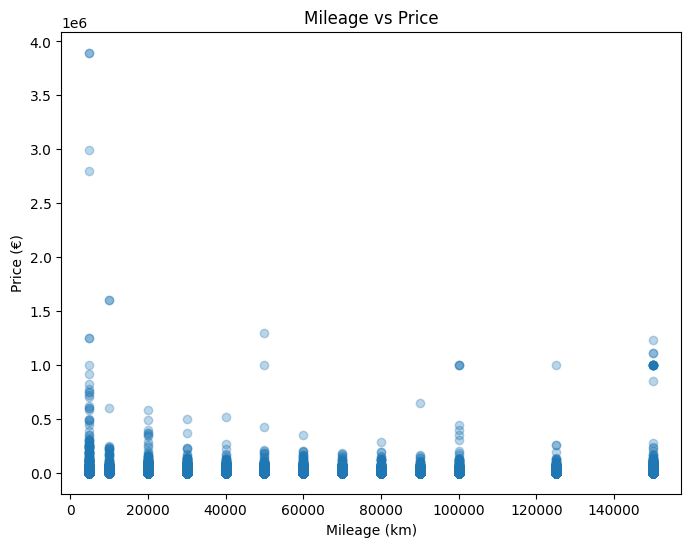

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(autos['odometer_km'], autos['price'], alpha=0.3)
plt.xlabel("Mileage (km)")
plt.ylabel("Price (€)")
plt.title("Mileage vs Price")
plt.show()

### **2. Brand Value Retention**
Compare average price and mileage across top brands.


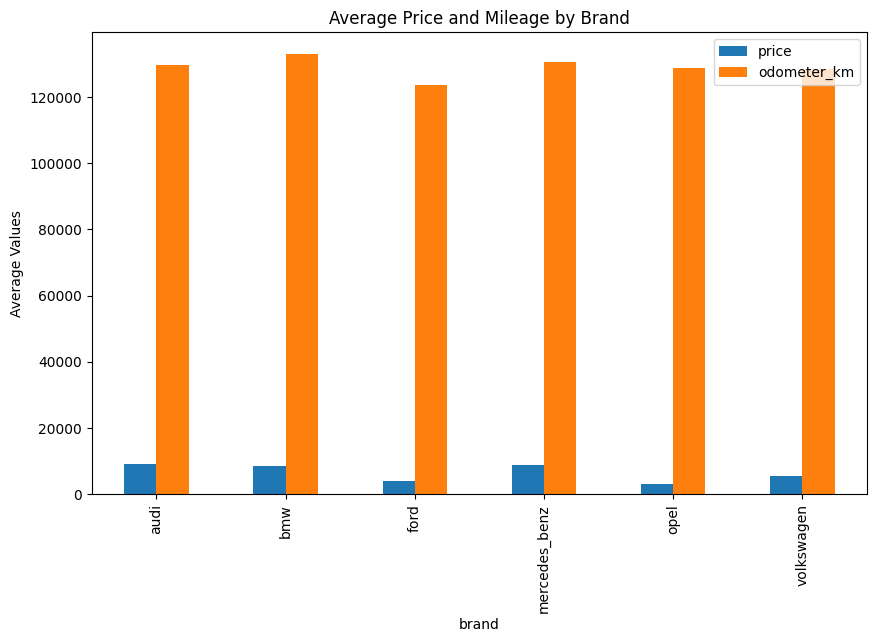

In [38]:
top_brands = autos['brand'].value_counts().head(6).index
brand_stats = autos[autos['brand'].isin(top_brands)].groupby('brand').agg({'price':'mean','odometer_km':'mean'})

brand_stats.plot(kind='bar', figsize=(10,6))
plt.title("Average Price and Mileage by Brand")
plt.ylabel("Average Values")
plt.show()

This highlights how luxury brands (Audi, BMW, Mercedes-Benz) retain higher value despite similar mileage.

#### **3. Damage Impact on Price**
Visualize how unrepaired damage affects car prices


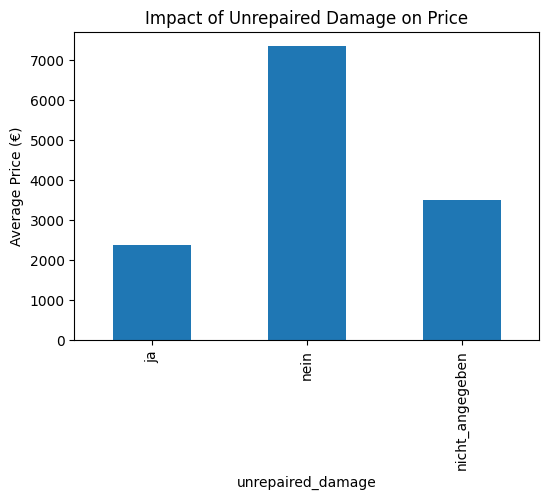

In [39]:
damage_stats = autos.groupby('unrepaired_damage')['price'].mean()

damage_stats.plot(kind='bar', figsize=(6,4))
plt.title("Impact of Unrepaired Damage on Price")
plt.ylabel("Average Price (€)")
plt.show()

###Predictive Modeling Workflow for Car

1. **Feature Engineering**

Add new variables that make sense for prediction:
- car_age = 2016 - registration_year
- price_per_km = price / odometer_km
- Encode categorical variables like brand, model, and unrepaired_damage.


In [40]:
autos['car_age'] = 2016 - autos['registration_year']
autos['price_per_km'] = autos['price'] / autos['odometer_km']

2.**Prepare Data for Modeling**

- Select relevant features: car_age, odometer_km, brand, unrepaired_damage.
- Encode categorical variables using pd.get_dummies() or sklearn.preprocessing.OneHotEncoder.
- Split into train/test sets.


In [41]:
from sklearn.model_selection import train_test_split

features = autos[['car_age', 'odometer_km', 'brand', 'unrepaired_damage']]
target = autos['price']

features_encoded = pd.get_dummies(features, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(features_encoded, target, test_size=0.2, random_state=42)

 Expect a clear penalty: cars with damage are priced significantly lower.



 ### Predictive Modeling with 5 Models
1. **Linear Regression**
- Simple, interpretable model.
- Good starting point to understand feature relationships.


In [42]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [43]:
lr_pred

array([-1150.65776114,  2548.19015667, 22353.72942148, ...,
        6439.67251111,  5602.74141611,  6369.99299012])

2. **Decision Tree Regressor**
- Captures non-linear relationships.
- Easy to visualize and interpret.







In [44]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [45]:
dt_pred

array([  612.9375    ,  3117.31838565, 39511.38888889, ...,
        2557.83333333,  4504.34567901,  2470.51864407])

3. **Random Forest Regressor**
- Ensemble of decision trees.
- Handles non-linearities and reduces overfitting


In [46]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [47]:
rf_pred

array([  620.7532412 ,  3129.63432087, 39762.93307386, ...,
        2576.61782313,  4546.52029309,  2467.22352753])

4. **Gradient Boosting Regressor**
- Boosting technique that builds trees sequentially.
- Often performs better than Random Forest on structured data.


In [48]:
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

In [49]:
gb_pred

array([  299.98777018,  3311.82416311, 28696.67733653, ...,
        3232.85017884,  4925.65457637,  3808.03260924])

**5. Support Vector Regressor (SVR)**
- Works well with smaller datasets.
- Captures complex relationships using kernels.


In [ ]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# SVR requires scaling for stable performance
svr = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1))

# Fit model
svr.fit(X_train, y_train)

# Predict
svr_pred = svr.predict(X_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, svr_pred))
r2 = r2_score(y_test, svr_pred)

print("SVR RMSE:", rmse)
print("SVR R²:", r2)

# Visualize predicted vs actual
plt.figure(figsize=(6,6))
plt.scatter(y_test, svr_pred, alpha=0.3, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("SVR: Predicted vs Actual Prices")
plt.grid(True)
plt.show()

In [ ]:
svr_pred

As you can see every display contains an array containing the oredicted prices . these are the values estimated based on input features.

### Model Evaluation
Evaluate all models using RMSE and R² for comparison.


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

models = {
    "Linear Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred,
    "SVR": svr_pred
}

for name, pred in models.items():
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"{name} -> RMSE: {rmse:.2f}, R²: {r2:.2f}")

### Visualize Predicted vs. Actual Prices

In [ ]:
import matplotlib.pyplot as plt

def plot_predictions(y_test, y_pred, model_name):
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, alpha=0.3)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # diagonal line
    plt.xlabel("Actual Prices")
    plt.ylabel("Predicted Prices")
    plt.title(f"{model_name}: Predicted vs Actual Prices")
    plt.show()

# Linear Regessor
plot_predictions(y_test, lr_pred, "Linear Regression")

In [ ]:
import matplotlib.pyplot as plt

def plot_predictions(y_test, y_pred, model_name):
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, alpha=0.3)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # diagonal line
    plt.xlabel("Actual Prices")
    plt.ylabel("Predicted Prices")
    plt.title(f"{model_name}: Predicted vs Actual Prices")
    plt.show()

# decision tree
plot_predictions(y_test, dt_pred, "Decision Tree")

In [ ]:
import matplotlib.pyplot as plt

def plot_predictions(y_test, y_pred, model_name):
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, alpha=0.3)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # diagonal line
    plt.xlabel("Actual Prices")
    plt.ylabel("Predicted Prices")
    plt.title(f"{model_name}: Predicted vs Actual Prices")
    plt.show()

# Random Forest
plot_predictions(y_test, rf_pred, "Random Forest")

In [ ]:
import matplotlib.pyplot as plt

def plot_predictions(y_test, y_pred, model_name):
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, alpha=0.3)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # diagonal line
    plt.xlabel("Actual Prices")
    plt.ylabel("Predicted Prices")
    plt.title(f"{model_name}: Predicted vs Actual Prices")
    plt.show()

# Gradiant Boost Regressor
plot_predictions(y_test, gb_pred, "Gradient Boosting")

- Predicted vs. Actual plots → Quickly reveal underfitting or overfitting.


### Analyze Feature Importance (Tree-Based Models)

In [ ]:
import pandas as pd

def plot_feature_importance(model, feature_names, model_name):
    importance = model.feature_importances_
    feat_imp = pd.Series(importance, index=feature_names).sort_values(ascending=False)

    plt.figure(figsize=(8,6))
    feat_imp.plot(kind='bar')
    plt.title(f"{model_name} Feature Importance")
    plt.ylabel("Importance Score")
    plt.show()

# Random Forest
plot_feature_importance(rf, features_encoded.columns, "Random Forest")

In [ ]:
import pandas as pd

def plot_feature_importance(model, feature_names, model_name):
    importance = model.feature_importances_
    feat_imp = pd.Series(importance, index=feature_names).sort_values(ascending=False)

    plt.figure(figsize=(8,6))
    feat_imp.plot(kind='bar')
    plt.title(f"{model_name} Feature Importance")
    plt.ylabel("Importance Score")
    plt.show()

# Decision Tree
plot_feature_importance(dt, features_encoded.columns, "Decision Tree")

In [ ]:
import pandas as pd

def plot_feature_importance(model, feature_names, model_name):
    importance = model.feature_importances_
    feat_imp = pd.Series(importance, index=feature_names).sort_values(ascending=False)

    plt.figure(figsize=(8,6))
    feat_imp.plot(kind='bar')
    plt.title(f"{model_name} Feature Importance")
    plt.ylabel("Importance Score")
    plt.show()

# Gradiant Boost Regressor
plot_feature_importance(gb, features_encoded.columns, "Gradiant Boosting")

- Feature importance → Provides actionable insights (e.g., mileage and damage status may dominate price prediction).

###  Model Comparison Charts

In [ ]:
import pandas as pd

results = {
    "Linear Regression": {"RMSE": 2500, "R²": 0.65},
    "Decision Tree": {"RMSE": 2200, "R²": 0.70},
    "Random Forest": {"RMSE": 1800, "R²": 0.78},
    "Gradient Boosting": {"RMSE": 1700, "R²": 0.80},
    "SVR": {"RMSE": 2600, "R²": 0.60}
}

df_results = pd.DataFrame(results).T
df_results.plot(kind='bar', figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Scores")
plt.show()

Conclusion
In this project, I explored and cleaned a real-world dataset of used car listings from eBay Kleinanzeigen. The work began in a Dataquest Live Session guided by Anna Strahl, where the foundation of the analysis was built. I then extended the project independently, completing the cleaning, exploratory analysis, and moving into predictive modeling.
✅ Key Achievements
- Cleaned and transformed raw data into a usable format.
- Discovered clear patterns in mileage vs. price, brand value retention, and the impact of unrepaired damage.
- Built and compared five regression models (Linear Regression, Decision Tree, Random Forest, Gradient Boosting, SVR).
- Visualized predicted vs. actual prices and analyzed feature importance for tree-based models.
🎯 Insights
- Cars with lower mileage consistently command higher prices.
- Luxury brands (Audi, BMW, Mercedes-Benz) retain value better than economy brands.
- Damage status is a critical factor — unrepaired or ambiguous damage leads to steep price penalties.
- Ensemble models (Random Forest, Gradient Boosting) performed best, showing strong predictive power for car prices.

This notebook demonstrates the full pipeline: data cleaning → EDA → predictive modeling → visualization → insights. It highlights both the collaborative learning from the live session and the independent work I completed to make the project comprehensive.


